In [1]:
# Cell 1: Environment Setup

include("scripts/initialization_helpers.jl")
include("scripts/initialization_dictionaries.jl")
using .InitializationHelpers
using .InitializationDictionaries
using OMJulia
using Plots, DataFrames, CSV

# --- Configuration ---

# 1. Directory containing the original dynamic package
MODEL_DIR = abspath("MyNordic")
MODELS_PKG_PATH = joinpath(MODEL_DIR, "package.mo")

# 2. Directory containing the auxiliary package generated by BuildAux_package.ipynb
AUX_DIR = abspath("MyNordic_auxiliary")
AUX_PACKAGE_FILE = joinpath(AUX_DIR, "package.mo")

# 3. Root dynamic model to initialize
MODEL = "MyNordic.TestCase"

# 4. Derived package/model names
SOURCE_PACKAGE = split(MODEL, ".")[1]
ROOT_MODEL_NAME = split(MODEL, ".")[end]

AUX_PACKAGE = SOURCE_PACKAGE * "_auxiliary"
AUX_ROOT_MODEL = AUX_PACKAGE * "." * ROOT_MODEL_NAME * "_auxiliary"

INITIALIZED_PACKAGE = SOURCE_PACKAGE * "_initialized"
INITIALIZED_DIR = joinpath(dirname(MODEL_DIR), INITIALIZED_PACKAGE)
INITIALIZED_ROOT_MODEL = INITIALIZED_PACKAGE * "." * ROOT_MODEL_NAME * "_initialized"
INITIALIZED_PACKAGE_FILE = joinpath(INITIALIZED_DIR, "package.mo")
INITIALIZED_ORDER_FILE = joinpath(INITIALIZED_DIR, "package.order")

# 5. Output directories for OpenModelica build artifacts
RUN_OUTPUT_DIR = abspath(INITIALIZED_PACKAGE * "_outputs")
mkpath(RUN_OUTPUT_DIR)

# 6. Library paths
DYNAWO_PKG_PATH = "/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo"
MODELICA_PKG_PATH = "/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo"

# 7. Placeholder plot variable for the final initialized simulation
PLOT_VARIABLE = "load_01.terminal.V.re"


"load_01.terminal.V.re"

In [2]:
# Cell 2: OpenModelica Setup + Package Loading

# 1. Load the original dynamic package
SourceOMC = OMJulia.OMCSession()
om_send(SourceOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
om_send(SourceOMC, "loadModel(Complex)")
om_send(SourceOMC, "loadModel(ModelicaServices)")
om_send(SourceOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
om_send(SourceOMC, "loadFile(\"$MODELS_PKG_PATH\")")
om_send(SourceOMC, "clearMessages()")
println("Checking the dynamic root model...")
chk_source = om_send(SourceOMC, "checkModel($MODEL)", parsed=false)
println(chk_source)

# 2. Load the auxiliary package
AuxOMC = OMJulia.OMCSession()
om_send(AuxOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
om_send(AuxOMC, "loadModel(Complex)")
om_send(AuxOMC, "loadModel(ModelicaServices)")
om_send(AuxOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
om_send(AuxOMC, "loadFile(\"$AUX_PACKAGE_FILE\")")
om_send(AuxOMC, "clearMessages()")
println("Checking the auxiliary root model...")
chk_aux = om_send(AuxOMC, "checkModel($AUX_ROOT_MODEL)", parsed=false)
println(chk_aux)


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.xqifoqMOPo"


OMC -> loadFile("/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo")
OMC -> loadModel(Complex)
OMC -> loadModel(ModelicaServices)
OMC -> loadFile("/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo")
OMC -> loadFile("/home/clarafercas/dynawo-notebooks/OpenModelica_only_users/Initialization/MyNordic/package.mo")
OMC -> clearMessages()
Checking the dynamic root model...
OMC -> checkModel(MyNordic.TestCase)


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.H2mXiyXKbA"


"Check of MyNordic.TestCase completed successfully.
Class MyNordic.TestCase has 6622 equation(s) and 6622 variable(s).
2846 of these are trivial equation(s)."

OMC -> loadFile("/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo")
OMC -> loadModel(Complex)
OMC -> loadModel(ModelicaServices)
OMC -> loadFile("/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo")
OMC -> loadFile("/home/clarafercas/dynawo-notebooks/OpenModelica_only_users/Initialization/MyNordic_auxiliary/package.mo")
OMC -> clearMessages()
Checking the auxiliary root model...
OMC -> checkModel(MyNordic_auxiliary.TestCase_auxiliary)
"Check of MyNordic_auxiliary.TestCase_auxiliary completed successfully.
Class MyNordic_auxiliary.TestCase_auxiliary has 5687 equation(s) and 5687 variable(s).
1550 of these are trivial equation(s)."



In [3]:
# Cell 3: INIT Model Mapping

INIT_MODEL_BY_COMPONENT = Dict{String, String}(
    "g01" => "GeneratorSynchronousExt3W_INIT",
    "g02" => "GeneratorSynchronousExt3W_INIT",
    "g03" => "GeneratorSynchronousExt3W_INIT",
    "g04" => "GeneratorSynchronousExt3W_INIT",
    "g05" => "GeneratorSynchronousExt3W_INIT",
    "g06" => "GeneratorSynchronousExt4W_INIT",
    "g07" => "GeneratorSynchronousExt4W_INIT",
    "g08" => "GeneratorSynchronousExt3W_INIT",
    "g09" => "GeneratorSynchronousExt3W_INIT",
    "g10" => "GeneratorSynchronousExt3W_INIT",
    "g11" => "GeneratorSynchronousExt3W_INIT",
    "g12" => "GeneratorSynchronousExt3W_INIT",
    "g13" => "GeneratorSynchronousExt3W_INIT",
    "g14" => "GeneratorSynchronousExt4W_INIT",
    "g15" => "GeneratorSynchronousExt4W_INIT",
    "g16" => "GeneratorSynchronousExt4W_INIT",
    "g17" => "GeneratorSynchronousExt4W_INIT",
    "g18" => "GeneratorSynchronousExt4W_INIT",
    "g19" => "GeneratorSynchronousExt3W_INIT",
    "g20" => "GeneratorSynchronousExt3W_INIT",
)


Dict{String, String} with 20 entries:
  "g02" => "GeneratorSynchronousExt3W_INIT"
  "g15" => "GeneratorSynchronousExt4W_INIT"
  "g09" => "GeneratorSynchronousExt3W_INIT"
  "g19" => "GeneratorSynchronousExt3W_INIT"
  "g13" => "GeneratorSynchronousExt3W_INIT"
  "g14" => "GeneratorSynchronousExt4W_INIT"
  "g12" => "GeneratorSynchronousExt3W_INIT"
  "g20" => "GeneratorSynchronousExt3W_INIT"
  "g11" => "GeneratorSynchronousExt3W_INIT"
  "g03" => "GeneratorSynchronousExt3W_INIT"
  "g05" => "GeneratorSynchronousExt3W_INIT"
  "g07" => "GeneratorSynchronousExt4W_INIT"
  "g16" => "GeneratorSynchronousExt4W_INIT"
  "g17" => "GeneratorSynchronousExt4W_INIT"
  "g06" => "GeneratorSynchronousExt4W_INIT"
  "g08" => "GeneratorSynchronousExt3W_INIT"
  "g18" => "GeneratorSynchronousExt4W_INIT"
  "g10" => "GeneratorSynchronousExt3W_INIT"
  "g04" => "GeneratorSynchronousExt3W_INIT"
  "g01" => "GeneratorSynchronousExt3W_INIT"

In [4]:
# Cell 4: Inheritance Chain + Package Name Mapping

chain = get_inheritance_chain(SourceOMC, MODEL)
println("Inheritance chain:")
println(chain)

INITIALIZED_NAME_MAP = Dict(model => INITIALIZED_PACKAGE * "." * split(model, ".")[end] * "_initialized" for model in chain)


OMC -> getInheritedClasses(MyNordic.TestCase)
OMC -> getInheritedClasses(MyNordic.FullDynamicModel)
OMC -> getInheritedClasses(MyNordic.NetworkWithAlphaBetaLoads)
OMC -> getInheritedClasses(MyNordic.Network)
Inheritance chain:
["MyNordic.Network", "MyNordic.NetworkWithAlphaBetaLoads", "MyNordic.FullDynamicModel", "MyNordic.TestCase"]


Dict{String, String} with 4 entries:
  "MyNordic.FullDynamicModel"          => "MyNordic_initialized.FullDynamicMode…
  "MyNordic.NetworkWithAlphaBetaLoads" => "MyNordic_initialized.NetworkWithAlph…
  "MyNordic.TestCase"                  => "MyNordic_initialized.TestCase_initia…
  "MyNordic.Network"                   => "MyNordic_initialized.Network_initial…

In [5]:
# Cell 5: Simulate Auxiliary Package + Extract Initialization Values

# Build and simulate the auxiliary root model.
ModelicaSystem(AuxOMC, AUX_PACKAGE_FILE, AUX_ROOT_MODEL, [MODELICA_PKG_PATH, DYNAWO_PKG_PATH])
simulate(AuxOMC, resultfile = AUX_PACKAGE * "_res.mat")

# Extract initialization values per original class in the inheritance chain.
initializable_by_model = Dict{String, Dict{String, Dict{String, Any}}}()
init_values_by_model = Dict{String, Dict{String, Dict{String, Float64}}}()

for model in chain
    components = get_all_components(SourceOMC, model)
    initializable_components = get_initializable_components(components, INIT_PARAMS, INIT_MODEL_BY_COMPONENT)
    init_values_by_component = extract_all_initialization_values(AuxOMC, components, INIT_PARAMS, INIT_MODEL_BY_COMPONENT)

    initializable_by_model[model] = initializable_components
    init_values_by_model[model] = init_values_by_component
end


In [6]:
# Cell 6: Build and save the initialized package
om_send(SourceOMC, "deleteClass($INITIALIZED_PACKAGE)")
om_send(SourceOMC, "clearMessages()")
om_send(SourceOMC, "loadString(\"within ; package $INITIALIZED_PACKAGE end $INITIALIZED_PACKAGE;\")")

for model in chain
    initialized_model = INITIALIZED_NAME_MAP[model]
    initialized_name = split(initialized_model, ".")[end]

    println("Copying and initializing ", model, " -> ", initialized_model)
    om_send(SourceOMC, "copyClass($model, \"$initialized_name\", $INITIALIZED_PACKAGE)")

    apply_initialization_modifiers!(
        SourceOMC,
        initialized_model,
        initializable_by_model[model],
        INIT_PARAMS,
        init_values_by_model[model],
        INIT_MODEL_BY_COMPONENT,
    )
end

mkpath(INITIALIZED_DIR)

open(INITIALIZED_PACKAGE_FILE, "w") do io
    print(io, "within ;\npackage $INITIALIZED_PACKAGE\nend $INITIALIZED_PACKAGE;\n")
end

open(INITIALIZED_ORDER_FILE, "w") do io
    for model in chain
        println(io, split(INITIALIZED_NAME_MAP[model], ".")[end])
    end
end

for model in chain
    initialized_model = INITIALIZED_NAME_MAP[model]
    initialized_name = split(initialized_model, ".")[end]
    initialized_file = joinpath(INITIALIZED_DIR, initialized_name * ".mo")

    txt = String(om_send(SourceOMC, "listFile($initialized_model)"))
    txt = rewrite_initialized_extends(txt, INITIALIZED_NAME_MAP)

    open(initialized_file, "w") do io
        print(io, txt)
        endswith(txt, "\n") || print(io, "\n")
    end
end

InitializedOMC = OMJulia.OMCSession()
om_send(InitializedOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
om_send(InitializedOMC, "loadModel(Complex)")
om_send(InitializedOMC, "loadModel(ModelicaServices)")
om_send(InitializedOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
om_send(InitializedOMC, "loadFile(\"$INITIALIZED_PACKAGE_FILE\")")
om_send(InitializedOMC, "clearMessages()")
println("Checking the initialized root model...")
chk_initialized = om_send(InitializedOMC, "checkModel($INITIALIZED_ROOT_MODEL)", parsed=false)
println(chk_initialized)


OMC -> deleteClass(MyNordic_initialized)
OMC -> clearMessages()
OMC -> loadString("within ; package MyNordic_initialized end MyNordic_initialized;")
Copying and initializing MyNordic.Network -> MyNordic_initialized.Network_initialized
OMC -> copyClass(MyNordic.Network, "Network_initialized", MyNordic_initialized)
Copying and initializing MyNordic.NetworkWithAlphaBetaLoads -> MyNordic_initialized.NetworkWithAlphaBetaLoads_initialized
OMC -> copyClass(MyNordic.NetworkWithAlphaBetaLoads, "NetworkWithAlphaBetaLoads_initialized", MyNordic_initialized)
OMC -> updateComponent(load_04, Dynawo.Electrical.Loads.LoadAlphaBeta, MyNordic_initialized.NetworkWithAlphaBetaLoads_initialized, modification = $Code((u0Pu = Complex(0.33087368251953253, -0.9432942167449838), i0Pu = Complex(0.4025267735226383, -8.76377098192977), alpha = Alpha, s0Pu = Complex(8.400000000000002, 2.52), beta = Beta)))
OMC -> updateComponent(load_46, Dynawo.Electrical.Loads.LoadAlphaBeta, MyNordic_initialized.NetworkWithAlphaBe

[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.EwKDHrqeJr"



OMC -> listFile(MyNordic_initialized.FullDynamicModel_initialized)
OMC -> listFile(MyNordic_initialized.TestCase_initialized)
OMC -> loadFile("/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo")
OMC -> loadModel(Complex)
OMC -> loadModel(ModelicaServices)
OMC -> loadFile("/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo")
OMC -> loadFile("/home/clarafercas/dynawo-notebooks/OpenModelica_only_users/Initialization/MyNordic_initialized/package.mo")
OMC -> clearMessages()
Checking the initialized root model...
OMC -> checkModel(MyNordic_initialized.TestCase_initialized)
"Check of MyNordic_initialized.TestCase_initialized completed successfully.
Class MyNordic_initialized.TestCase_initialized has 6622 equation(s) and 6622 variable(s).
2846 of these are trivial equation(s)."



In [7]:
# Cell 7: Final simulation of the initialized package

om_send(InitializedOMC, "clearMessages()")

ModelicaSystem(
    InitializedOMC,
    INITIALIZED_PACKAGE_FILE,
    INITIALIZED_ROOT_MODEL,
    [MODELICA_PKG_PATH, DYNAWO_PKG_PATH],
    customBuildDirectory = RUN_OUTPUT_DIR,
)

simflags = simulation_flags_without_log_stats(InitializedOMC, INITIALIZED_ROOT_MODEL)
initialized_resultfile_prefix = INITIALIZED_PACKAGE

sim_result = sendExpression(
    InitializedOMC,
    "simulate($INITIALIZED_ROOT_MODEL, outputFormat=\"csv\", fileNamePrefix=\"$initialized_resultfile_prefix\", simflags=\"$simflags\")",
    parsed = false,
)

println(sim_result)

initialized_resultfile = joinpath(
    getWorkDirectory(InitializedOMC),
    initialized_resultfile_prefix * "_res.csv",
)


OMC -> clearMessages()
record SimulationResult
    resultFile = "/home/clarafercas/dynawo-notebooks/OpenModelica_only_users/Initialization/MyNordic_initialized_outputs/MyNordic_initialized_res.csv",
    simulationOptions = "startTime = 0.0, stopTime = 169.8, numberOfIntervals = 16980, tolerance = 0.005, method = 'dassl', fileNamePrefix = 'MyNordic_initialized', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-s=euler -lssMaxDensity=0.1 -newtonMaxStepFactor=0.1'",
    messages = "LOG_STDOUT        | info    | Maximum density for using linear sparse solver changed to 0.100000
LOG_STDOUT        | info    | Maximum step size factor for a Newton step changed to 1e-12
LOG_STDOUT        | info    | Using sparse solver kinsol for nonlinear system 0 (4073),
|                 | |       | because density of 0.00 remains under threshold of 0.10
|                 | |       | and size of 1057 exceeds threshold of 1000.
LOG_STDOUT        | info    | The maximum den

"/home/clarafercas/dynawo-notebooks/OpenModelica_only_users/Initialization/MyNordic_initialized_outputs/MyNordic_initialized_res.csv"

WebIO._IJuliaInit()

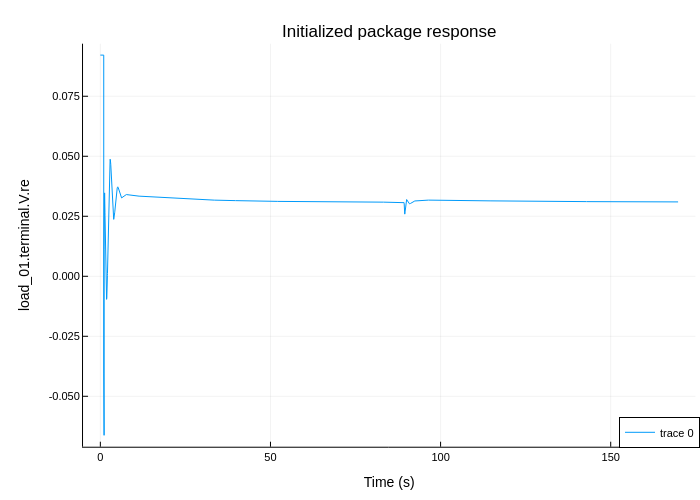

In [8]:
# Cell 8: Plot the initialized package response

initialized_df = DataFrame(CSV.File(initialized_resultfile; select = ["time", PLOT_VARIABLE]))

plotlyjs()
p = plot(initialized_df[!, "time"], initialized_df[!, PLOT_VARIABLE], label = [PLOT_VARIABLE])
plot!(p, legend = :bottomright, titlefontsize = 12, labelfontsize = 10)
title!(p, "Initialized package response")
xlabel!(p, "Time (s)")
ylabel!(p, PLOT_VARIABLE)


In [9]:
# Cell 9: Plot the other generator voltages

plot_generator = split(PLOT_VARIABLE, ".")[1]
voltage_suffix = join(split(PLOT_VARIABLE, ".")[2:end], ".")
csv_header = replace.(split(readline(initialized_resultfile), ","), "\"" => "")
generator_voltage_variables = [
    variable for variable in csv_header
    if occursin(r"^(Gen[0-9]+|g[0-9]+)\.", variable) && endswith(variable, "." * voltage_suffix)
]
other_voltage_variables = [variable for variable in generator_voltage_variables if split(variable, ".")[1] != plot_generator]

other_initialized_df = DataFrame(CSV.File(initialized_resultfile; select = vcat(["time"], other_voltage_variables)))

plotlyjs()
other_voltage_plots = Any[]
for variable in other_voltage_variables
    p_single = plot(
        other_initialized_df[!, "time"],
        other_initialized_df[!, variable],
        label = false,
        title = variable,
        xlabel = "Time (s)",
        ylabel = voltage_suffix,
        titlefontsize = 10,
        guidefontsize = 8,
        tickfontsize = 7,
    )
    push!(other_voltage_plots, p_single)
end
plot(other_voltage_plots..., layout = (5, 4), size = (1600, 1200))


LoadError: ArgumentError: column name :Gen1.terminal.V.re not found in the data frame

In [ ]:
# Cell 10: OMC diagnostics for failed initialized simulation

# Run this cell after the final simulation cell fails.

#=
println("=== Initialized package OMC diagnostics start ===")

if isdefined(Main, :InitializedOMC)
    print_omc_errors(InitializedOMC, "after failed final simulation cell")
end

DiagnosticOMC = OMJulia.OMCSession()
om_send(DiagnosticOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
om_send(DiagnosticOMC, "loadModel(Complex)")
om_send(DiagnosticOMC, "loadModel(ModelicaServices)")
om_send(DiagnosticOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
om_send(DiagnosticOMC, "loadFile(\"$INITIALIZED_PACKAGE_FILE\")")
om_send(DiagnosticOMC, "cd(\"$RUN_OUTPUT_DIR\")")
print_omc_errors(DiagnosticOMC, "after loading initialized package")

run_omc_diagnostic(DiagnosticOMC, "checkModel($INITIALIZED_ROOT_MODEL)", "checkModel($INITIALIZED_ROOT_MODEL)")

if isdefined(Main, :chain) && isdefined(Main, :INITIALIZED_NAME_MAP)
    for model in chain
        initialized_model = INITIALIZED_NAME_MAP[model]
        run_omc_diagnostic(DiagnosticOMC, "checkModel($initialized_model)", "checkModel($initialized_model)")
    end
end

run_omc_diagnostic(DiagnosticOMC, "instantiateModel($INITIALIZED_ROOT_MODEL)", "instantiateModel($INITIALIZED_ROOT_MODEL)")
run_omc_diagnostic(DiagnosticOMC, "buildModel($INITIALIZED_ROOT_MODEL)", "buildModel($INITIALIZED_ROOT_MODEL)")

println("=== Initialized package OMC diagnostics end ===")
=#
